# 제조 AI 2주차


## Step 1: SECOM 데이터 

Kaggle SECOM 데이터셋 
https://www.kaggle.com/datasets/paresh2047/uci-semcom

반도체 제조 공정에서 수집된 다양한 센서 및 공정 데이터를 기반으로, 각 웨이퍼의 양품·불량 여부가 레이블로 제공되는 정형 데이터셋입니다.

In [ ]:
# !pip install koreanize-matplotlib scikit-learn imbalanced-learn
import pandas as pd 
import koreanize_matplotlib
import numpy as np 

url= 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/'
X = pd.read_csv(url+ 'secom.data', sep=' ', header=None) # 590개의 센서 데이터
labels = pd.read_csv(url+ 'secom_labels.data', sep=' ', header=None)
y = (labels[0] == 1).astype(int) # -1(양품)→0, 1(불량)→1 로 변환
print(X.shape) # (1567, 590)

(1567, 590)


In [18]:
X.info() # 1567행 ×590열이며, 데이터 타입은 float64 
X.head(3) # 앞의 3개 행 출력

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 590 entries, 0 to 589
dtypes: float64(590)
memory usage: 7.1 MB


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602


0
0    1463
1     104
Name: count, dtype: int64
0.06636885768985322


<Axes: title={'center': '불량률'}, xlabel='불량 여부', ylabel='건수'>

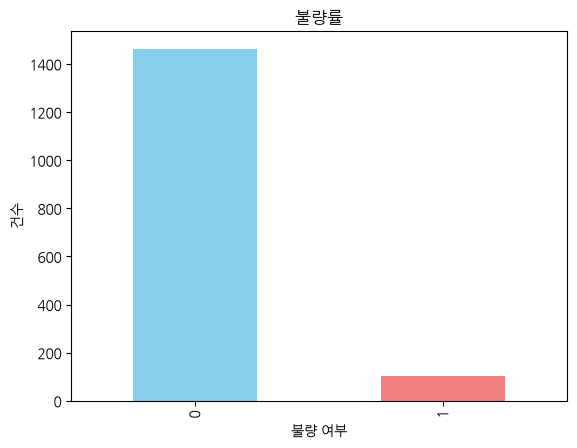

In [ ]:
print(y.value_counts()) # 0(양품): 1463, 1(불량): 104
print(y.mean()) # 불량률: 0.0663 약 6.63%
y.value_counts().plot(kind='bar', title='양품·불량 건수', xlabel='불량 여부', ylabel='건수', color=['skyblue', 'lightcoral']) # 불량률 시각화

## Step 2: EDA 진단

In [ ]:
miss = X.isna().mean().sort_values(ascending=False) # 결측치 비율 계산
print(miss.head(10)) # 결측치 비율이 높은 상위 10개 센서 출력
print(f"결측치 비율이 50% 이상인 열의 개수: {(miss>0.5).sum()}") # 결측치 비율이 50% 초과인 열의 개수 출력
print(f"결측치가 존재하는 열의 개수: {(miss>0).sum()}") # 결측치가 존재하는 열의 개수 출력


157    0.911934
292    0.911934
293    0.911934
158    0.911934
492    0.855775
358    0.855775
85     0.855775
220    0.855775
246    0.649649
109    0.649649
dtype: float64
결측치 비율이 50% 이상인 열의 개수: 28
결측치가 존재하는 열의 개수: 538


In [42]:
desc = X.describe().T # 통계적인 요약표 작성(평균, 표준편차, 최소값 등)  .T（전치)
print(desc.head(3)) #
print((desc['std'] == 0).sum()) # 표준 편차가 0인 열의 개수 출력
const_cols= desc[desc['std'] == 0].index
X[const_cols[:3]].head() # 모든 값이 동일한 상위 3개 센서 출력 (웨이퍼에서 값의 변화가 없는 센서)

    count         mean        std      min        25%        50%        75%  \
0  1561.0  3014.452896  73.621787  2743.24  2966.2600  3011.4900  3056.6500   
1  1560.0  2495.850231  80.407705  2158.75  2452.2475  2499.4050  2538.8225   
2  1553.0  2200.547318  29.513152  2060.66  2181.0444  2201.0667  2218.0555   

         max  
0  3356.3500  
1  2846.4400  
2  2315.2667  
116


,5,13,42
0,100.0,0.0,70.0
1,100.0,0.0,70.0
2,100.0,0.0,70.0
3,100.0,0.0,70.0
4,100.0,0.0,70.0


In [52]:
# 양품/불량별 센서 평균 계산
df= X.copy(); 
df['y'] = y


gap = df.groupby('y').mean().T # 센서별 양품/불량 평균 계산

# 양품(0)과 불량(1)의 평균 차이 계산
gap['diff'] = abs(gap[1] - gap[0])
print(gap.head(10)) # 센서별 양품/불량 평균과 평균 차이 출력

# 평균 차이가 큰 순서로 정렬
gap = gap.sort_values('diff', ascending=False)

# 상위 10개 센서 확인
print(gap.head(10)) 

y            0            1       diff
0  3014.947316  3007.526250   7.421066
1  2495.906115  2495.059709   0.846407
2  2200.554886  2200.441877   0.113009
3  1399.290292  1355.781435  43.508857
4     4.404698     1.303405   3.101293
5   100.000000   100.000000   0.000000
6   101.085773   101.490972   0.405199
7     0.121790     0.122257   0.000466
8     1.462309     1.470619   0.008310
9    -0.000715    -0.002608   0.001892
y              0            1        diff
161  4088.895349  3753.941748  334.953601
159   862.275650  1172.310680  310.035030
21  -5636.437585 -5362.274272  274.163314
24   -284.441518  -499.539641  215.098123
158  1027.456942  1237.799925  210.342983
160   541.604651   750.398058  208.793407
294   391.418291   549.383908  157.965617
162  4807.294118  4653.233010  154.061108
296  1887.538118  1761.278333  126.259785
295   246.059016   351.508144  105.449128


## Step 3: 전처리

In [58]:
# 전체 데이터를 앞 80%는 학습용, 뒤 20%는 테스트용으로 분할
n = len(X)
split = int(n * 0.8) 

# 데이터의 시간 순서를 유지하여 분할
X_train, X_test= X.iloc[:split], X.iloc[split:]
y_train, y_test= y.iloc[:split], y.iloc[split:]
print(X_train.shape, X_test.shape) # (1253, 590) (314, 590)

(1253, 590) (314, 590)


In [59]:
# 학습 데이터에서 각 센서(열)의 결측치 비율 계산
miss_tr= X_train.isna().mean()
# 결측치 비율이 50%를 초과하는 센서 찾기
drop_missing= miss_tr[miss_tr> 0.5].index 
# 학습 데이터에서 각 센서의 표준편차 계산
std_tr= X_train.std()
# 표준편차가 0인 센서(모든 측정값이 동일한 센서) 찾기
drop_const= std_tr[std_tr== 0].index 
# 제거할 센서 목록 합치기
drop_cols= drop_missing.union(drop_const)
# 학습 데이터에서 결정한 센서를 Train과 Test에서 동일하게 제거
X_train= X_train.drop(columns=drop_cols)
X_test= X_test.drop(columns=drop_cols) 

In [61]:
# 학습 데이터에서 각 센서(열)의 중앙값 계산
med = X_train.median() 
# 결측치를 학습 데이터의 중앙값으로 대체
X_train= X_train.fillna(med)
# 테스트 데이터도 학습 데이터에서 계산한 중앙값으로 대체
X_test= X_test.fillna(med) 
# 남아 있는 결측치 개수 확인
print(X_train.isna().sum().sum(), X_test.isna().sum().sum()) 

0 0


In [65]:
# ! pip install scikit-learn
from sklearn.preprocessing import StandardScaler

# 학습 데이터의 평균과 표준편차 계산
scaler = StandardScaler().fit(X_train)
# 학습 데이터의 평균과 표준편차를 기준으로 표준화
X_train_s= scaler.transform(X_train)
# 테스트 데이터도 학습 데이터의 평균과 표준편차를 기준으로 표준화
X_test_s= scaler.transform(X_test)
print(X_train_s.mean().round(3), X_train_s.std().round(3)) # ≈ 0.0, 1.0


0.0 1.0


In [69]:
# ! pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# SMOTE 적용 전 학습 데이터의 클래스 분포 확인
print('before:', y_train.value_counts().to_dict()) 
# 소수 클래스(불량) 데이터를 합성하여 클래스 균형 맞추기
X_res, y_res= SMOTE(random_state=42).fit_resample(X_train_s, y_train)

# SMOTE 적용 후 클래스 분포 확인
print('after :', pd.Series(y_res).value_counts().to_dict()) # 1:1 균형

before: {0: 1166, 1: 87}
after : {0: 1166, 1: 1166}


# SECOM EDA 리포트

아래의 내용을 추가해서 PDF로 출력해서 LMS에 제출하세요.

## 1. 데이터 개요

다음 내용을 확인하고 간단히 설명하세요.

- 데이터의 크기:

- 센서 변수의 개수:

- 양품/불량 데이터의 개수와 비율:

- 결측치 현황:

In [71]:
# 데이터 크기 확인
print(f"데이터의 크기: {X.shape[0]}, 센서(특징)의 개수: {X.shape[1]}")

# 양품/불량 개수 확인
print(f"양품: {y.value_counts()[0]}, 불량: {y.value_counts()[1]}")

# 양품/불량 비율 확인
print(f"양품: {y.value_counts(normalize=True)[0]:.3f}, 불량: {y.value_counts(normalize=True)[1]:.3f}")

# 센서별 결측치 비율 확인
missing = X.isna().mean()
print(f"결측치 비율:\n{missing.sort_values(ascending=False).head(10)}")

데이터의 크기: 1567, 센서(특징)의 개수: 590
양품: 1463, 불량: 104
양품: 0.934, 불량: 0.066
결측치 비율:
157    0.911934
292    0.911934
293    0.911934
158    0.911934
492    0.855775
358    0.855775
85     0.855775
220    0.855775
246    0.649649
109    0.649649
dtype: float64


## 2. 관찰과 가설

관심 있는 센서를 선택하여 히스토그램, 박스플롯 등
2개 이상의 그래프로 시각화하고 관찰 결과를 작성하세요.

### 관찰 결과
- 관찰 1:
- 관찰 2:

### 가설
- 가설 1:
- 가설 2:

## 3. 전처리 내역

수행한 전처리 과정과 그 이유를 설명하세요.

- 제거한 센서와 이유:
- 결측치 처리 방법:
- 표준화 방법:
- SMOTE 적용 여부 및 적용 전·후 클래스 비율:

## 4. 한 줄 결론

EDA 결과를 바탕으로 모델링에서 주목할 변수와 주의점을
한 문장으로 정리하세요.

> 결론: